In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Lapzone.pk\Downloads\airbnb (1).csv")



In [2]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64


In [4]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include=['object', 'string', 'category']).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nCleaned Dataset:")
print(df.head())


Missing values after handling:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Cleaned Dataset:
    id                      name host_id host_name neighbourhood_group  \
0   10            Spacious 2BR     75847     Maria            brooklyn   
1  286  Cozy apartment near park   84558     Chris       staten island   
2  675  Cozy apartment near park   20892    Daniel              QUEENS   
3  100  Cozy apartment near park   90224      Anna               

In [6]:
print("duplicate rows int the dataset:", df.duplicated().sum())



duplicate rows int the dataset: 0


In [7]:
df = df.drop_duplicates()

In [8]:
print("Number of duplicate rows after removal:", df.duplicated().sum())

Number of duplicate rows after removal: 0


In [9]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1009, 16)


In [17]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")



id: 0 outliers
latitude: 0 outliers
availability_365: 0 outliers


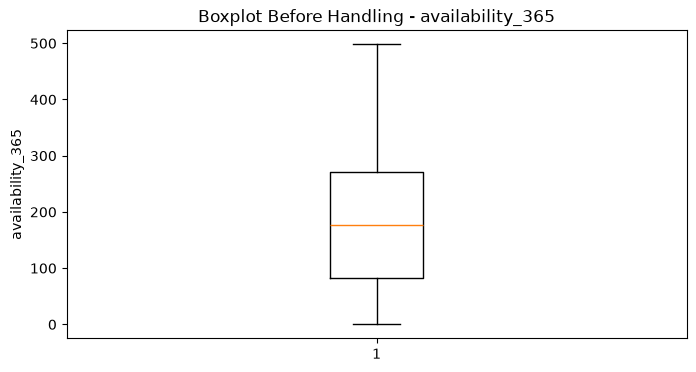

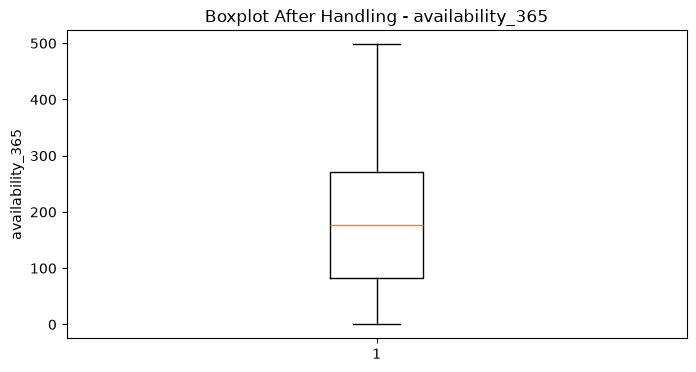

In [18]:
plt.figure(figsize=(8, 4))
plt.boxplot(df[col].dropna())
plt.title(f"Boxplot Before Handling - {col}")
plt.ylabel(col)
plt.show()
df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
plt.figure(figsize=(8, 4))
plt.boxplot(df[col].dropna())
plt.title(f"Boxplot After Handling - {col}")
plt.ylabel(col)
plt.show()

In [19]:

print("Data types before conversion:")
print(df[['price', 'minimum_nights', 'availability_365']].dtypes)


Data types before conversion:
price                 str
minimum_nights        str
availability_365    int64
dtype: object


In [25]:

print("\nData types after conversion:")
print(df[['price', 'minimum_nights', 'availability_365']].dtypes)



Data types after conversion:
price               float64
minimum_nights      float64
availability_365      int64
dtype: object


In [26]:
df['minimum_nights'] = df['minimum_nights'].astype(float)

print(df['minimum_nights'].dtype)
print(df[['minimum_nights']].head())

float64
   minimum_nights
0             5.0
1             1.0
2           365.0
3             1.0
4             1.0


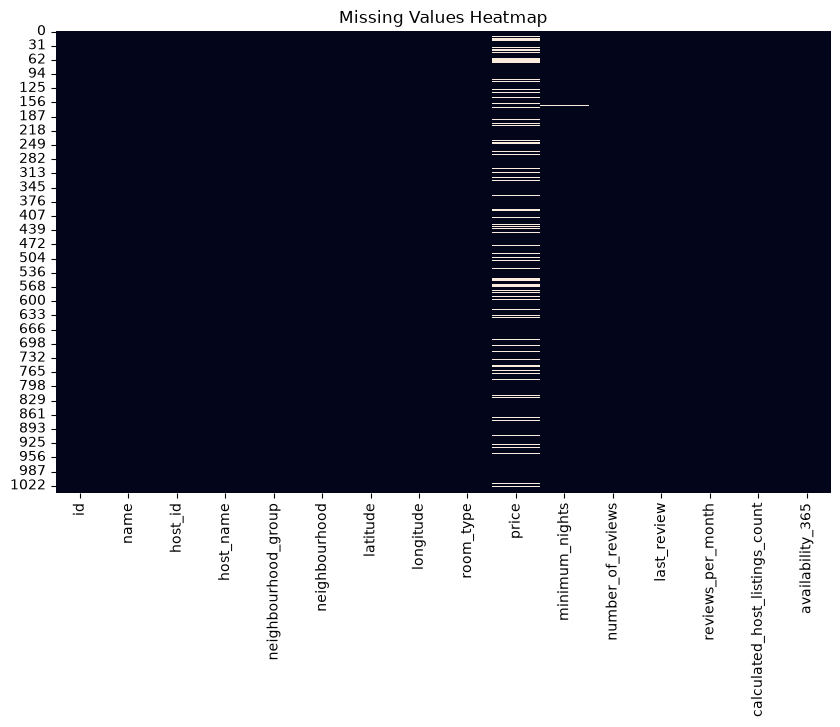

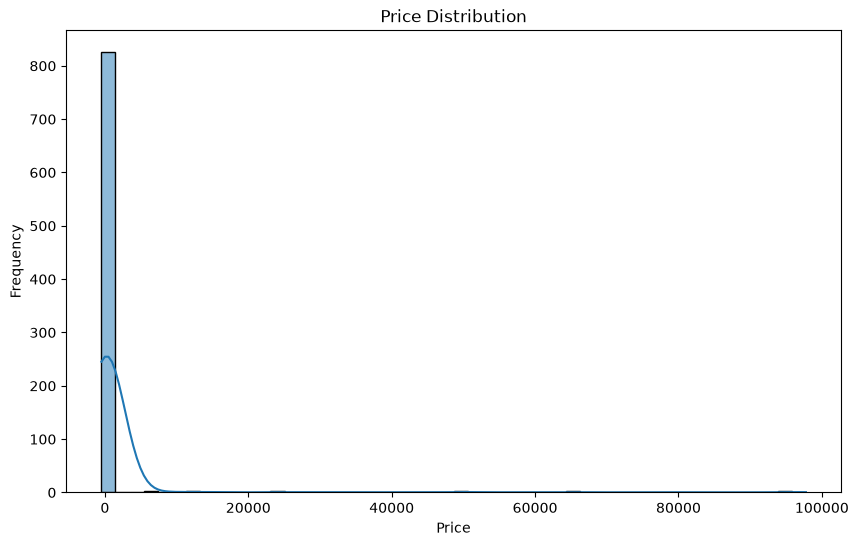

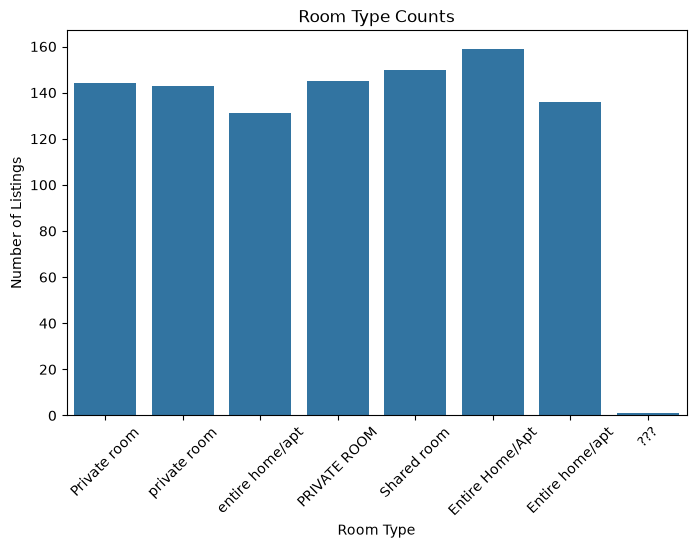

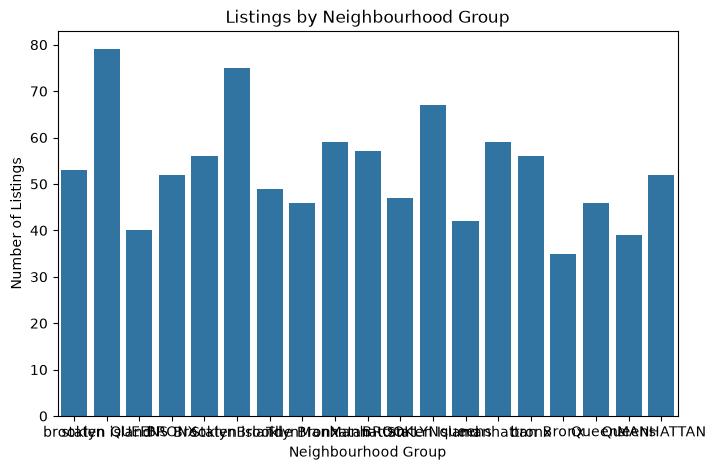

In [27]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='room_type')
plt.title("Room Type Counts")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='neighbourhood_group')
plt.title("Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.show()

In [28]:
print("Final Dataset Information:")
df.info()

print("\nFinal Missing Values:")
print(df.isnull().sum())

Final Dataset Information:
<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   str    
 2   host_id                         1009 non-null   str    
 3   host_name                       1009 non-null   str    
 4   neighbourhood_group             1009 non-null   str    
 5   neighbourhood                   1009 non-null   str    
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   str    
 8   room_type                       1009 non-null   str    
 9   price                           852 non-null    float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1009 non-null   str    
 12  last_review            

In [29]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['minimum_nights'] = pd.to_numeric(df['minimum_nights'], errors='coerce')

df['price'] = df['price'].fillna(df['price'].median())
df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())

print("Final Dataset Information:")
df.info()

print("\nFinal Missing Values:")
print(df.isnull().sum())

Final Dataset Information:
<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   str    
 2   host_id                         1009 non-null   str    
 3   host_name                       1009 non-null   str    
 4   neighbourhood_group             1009 non-null   str    
 5   neighbourhood                   1009 non-null   str    
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   str    
 8   room_type                       1009 non-null   str    
 9   price                           1009 non-null   float64
 10  minimum_nights                  1009 non-null   float64
 11  number_of_reviews               1009 non-null   str    
 12  last_review            